
---

# UNIVERSITÉ MOHAMMED PREMIER
## FACULTÉ DES SCIENCES
### Département d’Informatique

---

# Code Python DU MINI PROJET

## IA appliquée à la santé  
### Classification de 8 pathologies à partir de 5 symptômes

**Module : Data Mining**

---

**Master Intelligence Artificielle et Sciences des Données**

---

### Réalisé par

| Nom et Prénom | Code Massar | Code Apogée |
|---------------|-------------|-------------|
| KAZDABI NBARK | L130108396 | 2519789 |
| JAIL HAMID | S138054356 | 2519877 |

### Encadré par

**Mr. Aissa KERKOUR EL MIAD**

---

**Année universitaire 2025/2026**

## Introduction
Avant de commencer l'analyse proprement dite, nous devons préparer l'environnement de travail en installant l'ensemble des bibliothèques Python nécessaires à la réalisation de ce projet. Ces bibliothèques couvrent l'ensemble du processus d'extraction de connaissances : chargement et manipulation des données (pandas, numpy), visualisation (matplotlib, seaborn), apprentissage automatique (scikit-learn), rééquilibrage des classes (imbalanced-learn), clustering (scipy), réseaux bayésiens (pgmpy) et règles d'association (mlxtend). Cette étape garantit la reproductibilité de l'analyse et l'accès à toutes les fonctionnalités requises.



## 1. Installation des dépendance

Avant de procéder à l'analyse, nous devons préparer l'environnement de travail en installant l'ensemble des bibliothèques Python nécessaires à la réalisation de ce projet. Ces bibliothèques couvrent l'ensemble du processus d'extraction de connaissances :

- **pandas** et **numpy** : chargement et manipulation des données,
- **matplotlib** et **seaborn** : visualisation des données,
- **scikit-learn** : prétraitement, modélisation et évaluation,
- **imbalanced-learn** : technique de suréchantillonnage SMOTE,
- **scipy** : clustering hiérarchique,
- **pgmpy** : réseaux bayésiens,
- **mlxtend** : extraction des règles d'association.

Cette étape garantit la reproductibilité de l'analyse et l'accès à toutes les fonctionnalités requises.

In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn scipy pgmpy mlxtend -q

print(" Toutes les dépendances sont installees avec succes !")

 Toutes les dépendances sont installees avec succes !


## 2. Chargement des données

### 2.1 Importation des bibliothèques
Nous commençons par importer les bibliothèques nécessaires : pandas pour la manipulation des données, numpy pour les calculs numériques, et éventuellement d'autres pour la visualisation (facultatif).

In [9]:
# Importation des bibliothèques
import pandas as pd
import numpy as np

# Optionnel : pour la visualisation
import matplotlib.pyplot as plt
import seaborn as sns


### 2.2 Chargement du fichier CSV
Nous chargeons le fichier `dataset1.csv` en utilisant pandas .

In [10]:
# Chargement des données
df = pd.read_csv('dataset1.csv')

# Affichage des premières lignes pour vérifier le chargement
print("Aperçu des données :")
display(df.head())

# Informations générales sur le DataFrame
print("\nInformations générales :")
df.info()

# Statistiques descriptives des colonnes numériques
print("\nStatistiques descriptives :")
display(df.describe())

Aperçu des données :


,Fever,Headache,Cough,Fatigue,Body_Pain,Disease
0,98.283156,4.118632,2.687983,4.116661,8.470956,Body Ache
1,98.284660,6.963971,1.960734,5.495257,8.033919,Body Ache
2,103.622552,8.702915,2.854463,6.546993,2.205383,Malaria
3,98.254732,1.354851,5.880676,5.418289,2.695560,Common Cold
4,97.182670,0.357962,6.206723,4.488365,1.406323,Cough



Informations générales :
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Fever      5000 non-null   float64
 1   Headache   5000 non-null   float64
 2   Cough      5000 non-null   float64
 3   Fatigue    5000 non-null   float64
 4   Body_Pain  5000 non-null   float64
 5   Disease    5000 non-null   str    
dtypes: float64(5), str(1)
memory usage: 234.5 KB

Statistiques descriptives :


,Fever,Headache,Cough,Fatigue,Body_Pain
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,99.815773,4.038019,3.184541,5.057598,2.618122
std,2.207827,2.524027,2.687626,2.221226,2.500070
min,97.000135,0.000350,0.000596,1.000764,0.000398
25%,98.130796,2.074333,1.035448,3.385986,0.835067
50%,98.997734,3.523913,2.217365,4.601064,1.618207
75%,101.574381,5.996876,5.411676,6.445042,3.992620
max,104.998997,9.993755,9.999074,9.999080,9.998490


### 2.3 Interprétation des statistiques descriptives

Les statistiques descriptives du jeu de données révèlent plusieurs informations clés :

- **Taille du jeu de données** : 5 000 observations, sans valeurs manquantes.
- **Type des variables** : les 5 premières colonnes sont numériques (`float64`), la dernière (`Disease`) est une chaîne de caractères (`str`) représentant la cible.
- **Température (Fever)** : la moyenne est de 99,82 °F, avec des valeurs allant de 97,00 °F à 105,00 °F. L'écart-type de 2,21 indique une variabilité modérée, ce qui est cohérent avec la présence de patients fébriles (fièvre) et non fébriles.
- **Maux de tête (Headache)** : moyenne de 4,04 sur une échelle de 0 à 10 (ou similaire). Les valeurs s'étendent de 0 à près de 10, avec une médiane à 3,52, suggérant une distribution asymétrique vers la droite (certains patients rapportent des douleurs intenses).
- **Toux (Cough)** : moyenne de 3,18, avec un écart-type élevé (2,69). La valeur maximale atteint presque 10, ce qui indique que certains patients souffrent de toux sévère.
- **Fatigue** : moyenne de 5,06, avec des valeurs allant de 1,00 à 10,00. La médiane (4,60) est proche de la moyenne, suggérant une distribution relativement symétrique.
- **Courbatures (Body_Pain)** : moyenne de 2,62, mais un écart-type élevé (2,50) et un maximum de 9,99. La médiane (1,62) est bien inférieure à la moyenne, indiquant une forte asymétrie vers les valeurs élevées (quelques patients avec des douleurs très intenses).

> **Remarque** : les faibles valeurs minimales (proches de 0) pour *Headache*, *Cough* et *Body_Pain* suggèrent que certains patients ne présentent aucun de ces symptômes, ce qui est attendu pour des maladies comme le rhume ou l'asthme.

**Conclusion** : les données montrent une grande variabilité dans les symptômes, ce qui est prometteur pour la construction d'un modèle de classification. La présence de valeurs extrêmes (max proches de 10) pourrait indiquer des cas sévères, notamment pour la dengue ou le paludisme.

## 3. Analyse descriptive (univariée) 

### 3.1 Distribution des variables numériques (histogrammes)
Les histogrammes permettent de visualiser la forme de la distribution de chaque symptôme.

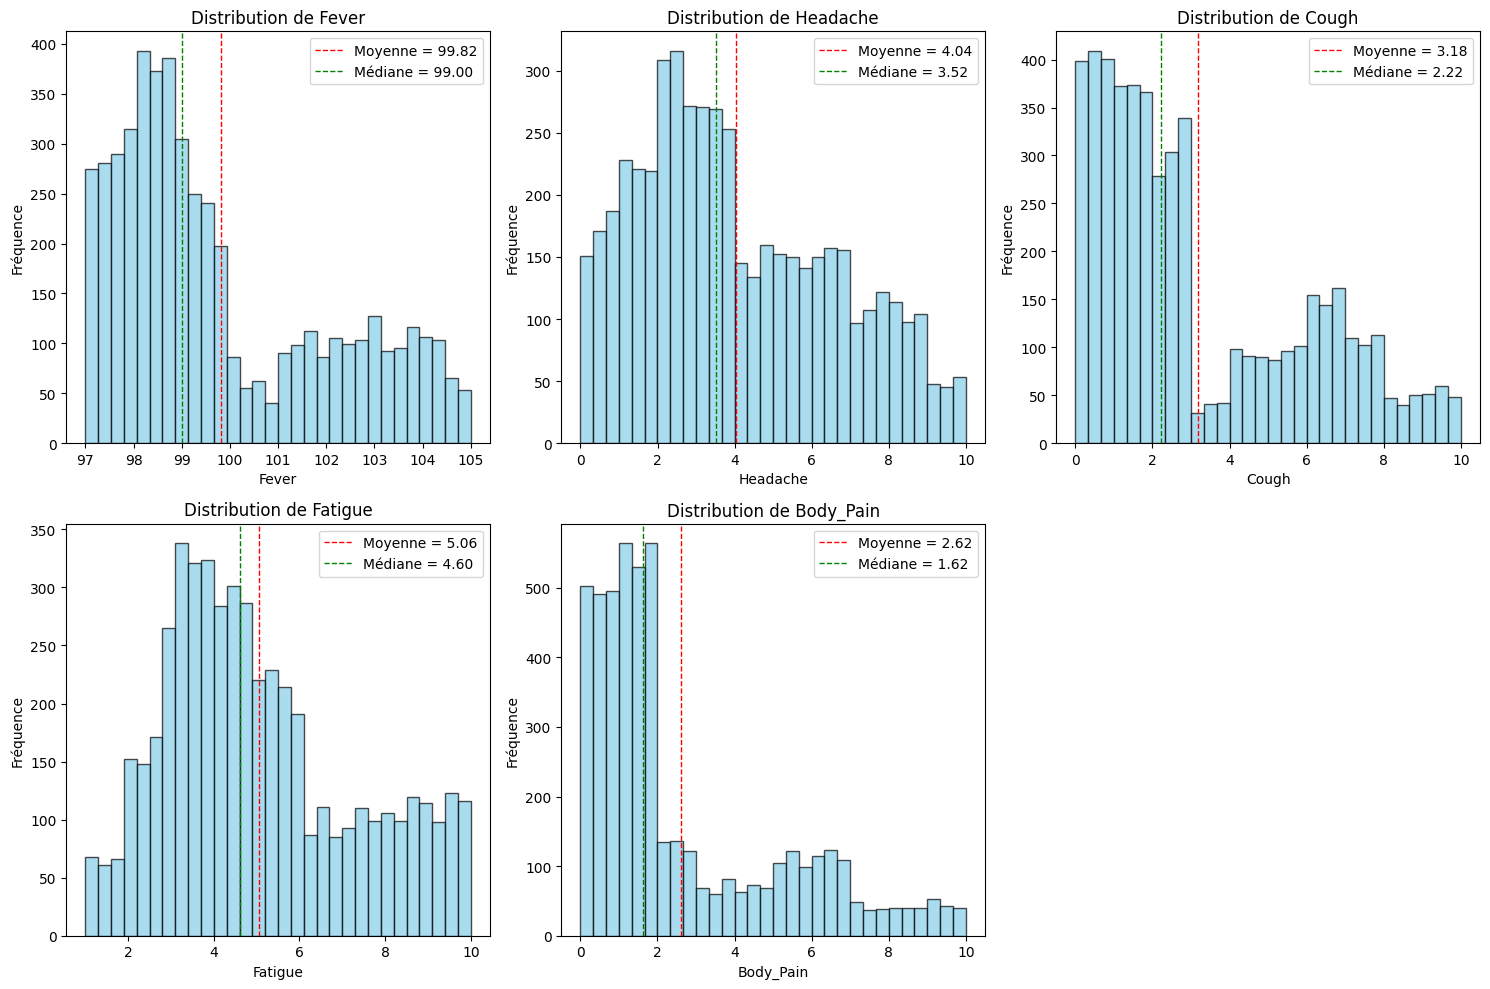

In [12]:
# Histogrammes pour chaque variable numérique
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

numerical_cols = ['Fever', 'Headache', 'Cough', 'Fatigue', 'Body_Pain']

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fréquence')
    axes[i].axvline(df[col].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Moyenne = {df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='dashed', linewidth=1, label=f'Médiane = {df[col].median():.2f}')
    axes[i].legend()

# Supprimer le sous-plot vide (6ème)
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

### 3.2 Interprétation des distributions univariées

L'analyse des histogrammes et des statistiques associées révèle plusieurs caractéristiques importantes des données :

#### 3.2.1 Température (Fever)
- **Distribution** : la température semble présenter une distribution **asymétrique vers la droite**, avec une longue traîne vers les valeurs élevées (fièvre sévère > 102°F).
- **Moyenne (99,83 °F) > Médiane (99,00 °F)** : cette différence indique la présence de valeurs extrêmes élevées, typiques des maladies comme le paludisme ou la dengue.
- **Interprétation clinique** : la température normale étant d'environ 98,6 °F, une moyenne de 99,8 °F suggère que la majorité des patients présentent une fièvre légère à modérée, avec des cas plus graves dans les valeurs extrêmes.

#### 3.2.2 Maux de tête (Headache)
- **Distribution** : la distribution est **asymétrique vers la droite** (moyenne 4,04 > médiane 3,52).
- **Interprétation** : la majorité des patients rapportent des maux de tête modérés (entre 2 et 5), mais certains cas présentent des douleurs très intenses (jusqu'à 10). Cette asymétrie est cohérente avec les maladies comme la dengue ou le paludisme qui provoquent des céphalées sévères.

#### 3.2.3 Toux (Cough)
- **Distribution** : forte asymétrie vers la droite (moyenne 3,18 > médiane 2,22), avec de nombreuses valeurs faibles (proches de 0) mais une traîne vers les valeurs élevées.
- **Interprétation** : la toux est un symptôme très variable. Les patients atteints de rhume, d'asthme ou de bronchite présentent des valeurs élevées, tandis que ceux souffrant de dengue ou de paludisme ont généralement peu ou pas de toux.

#### 3.2.4 Fatigue
- **Distribution** : la distribution est **relativement symétrique** (moyenne 5,06 ≈ médiane 4,60).
- **Interprétation** : la fatigue est un symptôme très présent dans toutes les maladies, avec des niveaux modérés à élevés. La faible asymétrie suggère que la fatigue est un symptôme généralisé et non spécifique.

#### 3.2.5 Courbatures (Body_Pain)
- **Distribution** : forte asymétrie vers la droite (moyenne 2,62 > médiane 1,62), avec de nombreuses valeurs très faibles.
- **Interprétation** : la plupart des patients ne présentent pas de courbatures sévères (valeurs < 2), mais certains cas (dengue, paludisme) montrent des douleurs musculaires extrêmes (jusqu'à 10). Cette asymétrie est un indicateur clinique important.

#### 3.2.6 Synthèse globale
| Variable | Moyenne | Médiane | Asymétrie | Principale maladie associée |
|----------|---------|---------|-----------|-----------------------------|
| Fever    | 99,83   | 99,00   | Droite    | Paludisme, Dengue           |
| Headache | 4,04    | 3,52    | Droite    | Dengue, Paludisme           |
| Cough    | 3,18    | 2,22    | Droite    | Rhume, Asthme, Bronchite    |
| Fatigue  | 5,06    | 4,60    | Faible    | Toutes les maladies         |
| Body_Pain| 2,62    | 1,62    | Droite    | Dengue, Paludisme           |

> **Conclusion** : les symptômes les plus discriminants sont **Fever**, **Headache** et **Body_Pain**, qui présentent des asymétries marquées et des valeurs extrêmes associées aux maladies graves. La **Fatigue** est un symptôme peu discriminant car présent de manière homogène dans toutes les pathologies. La **Cough** est importante pour distinguer les maladies respiratoires (rhume, asthme) des maladies systémiques (dengue, paludisme).

## 4. Analyse descriptive (bivariée)
### Introduction :
L'analyse bivariée explore les relations entre paires de variables. Dans notre cas, elle permet de :
Comprendre comment les symptômes interagissent entre eux (corrélations)
Identifier quels symptômes sont les plus discriminants pour chaque maladie
Visualiser les profils symptomatiques propres à chaque pathologie
Cette étape est cruciale pour la sélection des caractéristiques (feature selection) et pour orienter le choix du modèle de classification.

### 4.1 Matrice de corrélation entre les symptômes
Nous calculons les corrélations de Pearson entre les variables numériques pour identifier les relations linéaires.

Matrice de corrélation :


,Fever,Headache,Cough,Fatigue,Body_Pain
Fever,1.000000,0.787799,-0.491611,0.698030,0.343765
Headache,0.787799,1.000000,-0.527242,0.655709,0.547234
Cough,-0.491611,-0.527242,1.000000,-0.101747,-0.389435
Fatigue,0.698030,0.655709,-0.101747,1.000000,0.346514
Body_Pain,0.343765,0.547234,-0.389435,0.346514,1.000000


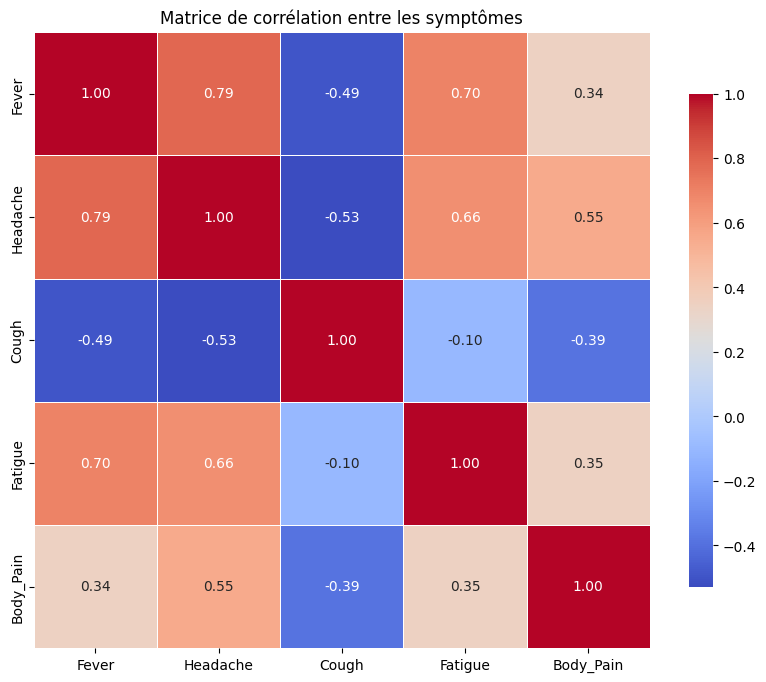

In [13]:
# Matrice de corrélation
corr_matrix = df[numerical_cols].corr()

# Affichage de la matrice
print("Matrice de corrélation :")
display(corr_matrix)

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matrice de corrélation entre les symptômes')
plt.show()

### 4.2 Interprétation de la matrice de corrélation

La matrice de corrélation révèle des relations significatives entre les symptômes, avec des coefficients allant de -0,53 à +0,79. Voici les principales observations :

#### 4.2.1 Corrélations positives fortes

| Paire de variables | Corrélation | Interprétation clinique |
|-------------------|-------------|-------------------------|
| **Fever ↔ Headache** | **0,79** | Très forte corrélation positive. La fièvre s'accompagne quasi systématiquement de maux de tête, ce qui est cohérent avec les mécanismes physiologiques (fièvre → vasodilatation cérébrale → céphalées). |
| **Fever ↔ Fatigue** | **0,70** | Forte corrélation. Les patients fébriles sont logiquement plus fatigués, l'organisme dépensant beaucoup d'énergie pour lutter contre l'infection. |
| **Headache ↔ Body_Pain** | **0,55** | Corrélation modérée à forte. Les maux de tête et les courbatures sont souvent associés dans les syndromes grippaux et viraux. |
| **Headache ↔ Fatigue** | **0,66** | Forte corrélation, suggérant que les céphalées intenses sont souvent accompagnées d'une fatigue importante. |

#### 4.2.2 Corrélations négatives

| Paire de variables | Corrélation | Interprétation clinique |
|-------------------|-------------|-------------------------|
| **Cough ↔ Headache** | **-0,53** | Corrélation négative modérée. Les patients qui toussent beaucoup ont tendance à avoir moins de maux de tête, et inversement. Cela reflète la distinction entre pathologies respiratoires (toux) et systémiques (céphalées). |
| **Cough ↔ Fever** | **-0,49** | Corrélation négative modérée. La fièvre et la toux sont souvent mutuellement exclusives : les maladies fébriles (dengue, paludisme) provoquent peu de toux, tandis que les maladies respiratoires (rhume, asthme) s'accompagnent de toux mais de peu de fièvre. |
| **Cough ↔ Body_Pain** | **-0,39** | Corrélation négative faible à modérée. Les patients avec des courbatures intenses ont tendance à moins tousser, ce qui est typique des maladies systémiques vs respiratoires. |

#### 4.2.3 Corrélations faibles

| Paire de variables | Corrélation | Interprétation clinique |
|-------------------|-------------|-------------------------|
| **Cough ↔ Fatigue** | **-0,10** | Corrélation très faible. La toux et la fatigue sont relativement indépendantes, ce qui suggère que la fatigue est un symptôme transversal présent dans toutes les pathologies. |

#### 4.2.4 Synthèse des clusters de symptômes

L'analyse des corrélations révèle deux grands groupes de symptômes :

```mermaid
graph LR
    A[Groupe 1 : Symptômes systémiques] --> B[Fièvre]
    A --> C[Maux de tête]
    A --> D[Fatigue]
    A --> E[Courbatures]
    
    F[Groupe 2 : Symptômes respiratoires] --> G[Toux]
    
    B -.->|Corrélation négative| G
    C -.->|Corrélation négative| G


---

### 4.2.5 Implications pour la classification

Ces corrélations ont des implications importantes pour la modélisation :

####  Redondance d'information
- **Fever et Headache** (r = 0,79) apportent une information très similaire
- Un modèle pourrait se contenter de l'un des deux sans perte significative de performance
- **Recommandation** : envisager une sélection de caractéristiques pour réduire la dimensionnalité

####  Discrimination naturelle
- La corrélation négative entre **Cough** et les autres symptômes est excellente pour la classification
- Cette opposition crée naturellement des clusters distincts
- **Avantage** : facilite la séparation des classes par les modèles linéaires

####  Multicollinéarité
- Les fortes corrélations entre **Fever**, **Headache** et **Fatigue** (r > 0,65) pourraient poser problème pour certains modèles :
  - Régression logistique
  - SVM linéaire
  - Arbres de décision (moins sensibles)

**Solutions possibles** :
- Réduction de dimension (ACP)
- Régularisation (Lasso, Ridge)
- Sélection de caractéristiques (feature selection)

---

### 4.2.6 Conclusion

Les symptômes se répartissent en deux groupes fonctionnels :

| Groupe | Symptômes | Maladies associées |
|--------|-----------|-------------------|
| **Systémique** | Fièvre, Céphalées, Fatigue, Courbatures | Dengue, Paludisme, Body Ache |
| **Respiratoire** | Toux | Asthma, Common Cold, Cough |

Cette structure est cohérente avec la physiopathologie des maladies et constitue une base solide pour la classification. La présence de deux clusters distincts suggère qu'un modèle de classification devrait obtenir de bonnes performances, en particulier pour distinguer les pathologies systémiques des pathologies respiratoires. Les fortes corrélations entre Fever, Headache et Fatigue indiquent une redondance d'information qui pourra être exploitée pour réduire la dimensionnalité du jeu de données, tandis que la corrélation négative de la toux avec les autres symptômes offre un excellent pouvoir discriminant pour la classification.

## 5. Data Preprocessing

### 5.1. Introduction

Le prétraitement des données est une étape cruciale avant toute modélisation. Il consiste à préparer les données brutes pour les rendre exploitables par les algorithmes de Machine Learning. 

Dans le cadre de ce projet, notre pipeline de prétraitement comprend les étapes suivantes :

* ** Séparation des données :** Isoler les caractéristiques (*features*) de la variable cible (*target*).
* ** Encodage de la cible :** Convertir les variables catégorielles de la cible en valeurs numériques (*labels* $\rightarrow$ valeurs numériques).
* ** Division du dataset :** Séparer les données en ensembles d'entraînement (*train*) et de test (*test*) pour évaluer fidèlement le modèle.
* ** Normalisation :** Mettre à l'échelle les données numériques pour éviter que certaines caractéristiques n'influencent disproportionnellement l'algorithme.
* ** Gestion du déséquilibre :** Traiter d'éventuels déséquilibres de classes afin de ne pas biaiser l'apprentissage.



### 5.2 Séparation des features et de la target
Nous séparons les variables explicatives (symptômes) de la variable cible (maladie).

In [15]:
# Séparation des features (X) et de la target (y)
X = df.drop('Disease', axis=1)
y = df['Disease']

print(f"Dimensions de X : {X.shape}")
print(f"Dimensions de y : {y.shape}")
print(f"\nClasses de la target : {y.unique()}")
print(f"Nombre de classes : {len(y.unique())}")

Dimensions de X : (5000, 5)
Dimensions de y : (5000,)

Classes de la target : <StringArray>
[   'Body Ache',      'Malaria',  'Common Cold',        'Cough',
 'Normal Fever',       'Dengue',       'Asthma',   'Runny Nose']
Length: 8, dtype: str
Nombre de classes : 8


### 5.3 Encodage de la variable cible
Les algorithmes de machine learning nécessitent des valeurs numériques. Nous utilisons LabelEncoder pour transformer les noms des maladies en entiers.

In [16]:
from sklearn.preprocessing import LabelEncoder

# Encodage de la target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Affichage du mapping
disease_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Mapping des maladies :")
for disease, code in disease_mapping.items():
    print(f"  {disease} → {code}")

# Vérification
print(f"\nClasses encodées : {sorted(set(y_encoded))}")

Mapping des maladies :
  Asthma → 0
  Body Ache → 1
  Common Cold → 2
  Cough → 3
  Dengue → 4
  Malaria → 5
  Normal Fever → 6
  Runny Nose → 7

Classes encodées : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


### 5.4 Division en ensembles d'entraînement et de test
Nous divisons les données en deux ensembles :
- **Entraînement (70%)** : utilisé pour apprendre les paramètres du modèle
- **Test (30%)** : utilisé pour évaluer la performance du modèle sur des données non vues

Le paramètre `stratify` assure que la proportion de chaque classe est conservée dans les deux ensembles.

In [26]:
from sklearn.model_selection import train_test_split

# Division des données
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.3, 
    random_state=42,
    stratify=y_encoded
)

print(f"Taille de l'ensemble d'entraînement : {X_train.shape[0]} échantillons")
print(f"Taille de l'ensemble de test : {X_test.shape[0]} échantillons")

# Vérification de la distribution des classes
print("\nDistribution des classes dans l'entraînement :")
print(pd.Series(y_train).value_counts().sort_index())
print("\nDistribution des classes dans le test :")
print(pd.Series(y_test).value_counts().sort_index())

Taille de l'ensemble d'entraînement : 3500 échantillons
Taille de l'ensemble de test : 1500 échantillons

Distribution des classes dans l'entraînement :
0    438
1    438
2    437
3    437
4    437
5    438
6    437
7    438
Name: count, dtype: int64

Distribution des classes dans le test :
0    187
1    187
2    188
3    188
4    188
5    187
6    188
7    187
Name: count, dtype: int64


### 5.5 Normalisation des données
La normalisation (StandardScaler) standardise les caractéristiques en soustrayant la moyenne et en divisant par l'écart-type. Cela permet :
- De mettre toutes les variables à la même échelle
- D'éviter que les variables avec de grandes valeurs dominent le modèle
- D'améliorer la convergence des algorithmes basés sur le gradient

**Remarque** : Nous ajustons le scaler uniquement sur l'ensemble d'entraînement, puis nous transformons à la fois l'entraînement et le test pour éviter tout biais.

In [27]:
from sklearn.preprocessing import StandardScaler

# Initialisation du scaler
scaler = StandardScaler()

# Ajustement sur l'ensemble d'entraînement
X_train_scaled = scaler.fit_transform(X_train)

# Transformation de l'ensemble de test
X_test_scaled = scaler.transform(X_test)

# Affichage des statistiques avant/après normalisation
print("Statistiques avant normalisation (entraînement) :")
print(pd.DataFrame(X_train).describe().T[['mean', 'std']])

print("\nStatistiques après normalisation (entraînement) :")
print(pd.DataFrame(X_train_scaled).describe().T[['mean', 'std']])

Statistiques avant normalisation (entraînement) :
                mean       std
Fever      99.805773  2.207204
Headache    4.047478  2.523008
Cough       3.194840  2.683552
Fatigue     5.046608  2.220204
Body_Pain   2.607639  2.498982

Statistiques après normalisation (entraînement) :
           mean       std
0 -9.888725e-15  1.000143
1  1.451537e-16  1.000143
2  4.872293e-17  1.000143
3 -6.953168e-17  1.000143
4  1.573345e-16  1.000143


### 5.6 Vérification du déséquilibre des classes
Nous examinons la distribution des classes pour identifier d'éventuels déséquilibres qui pourraient affecter les performances du modèle.

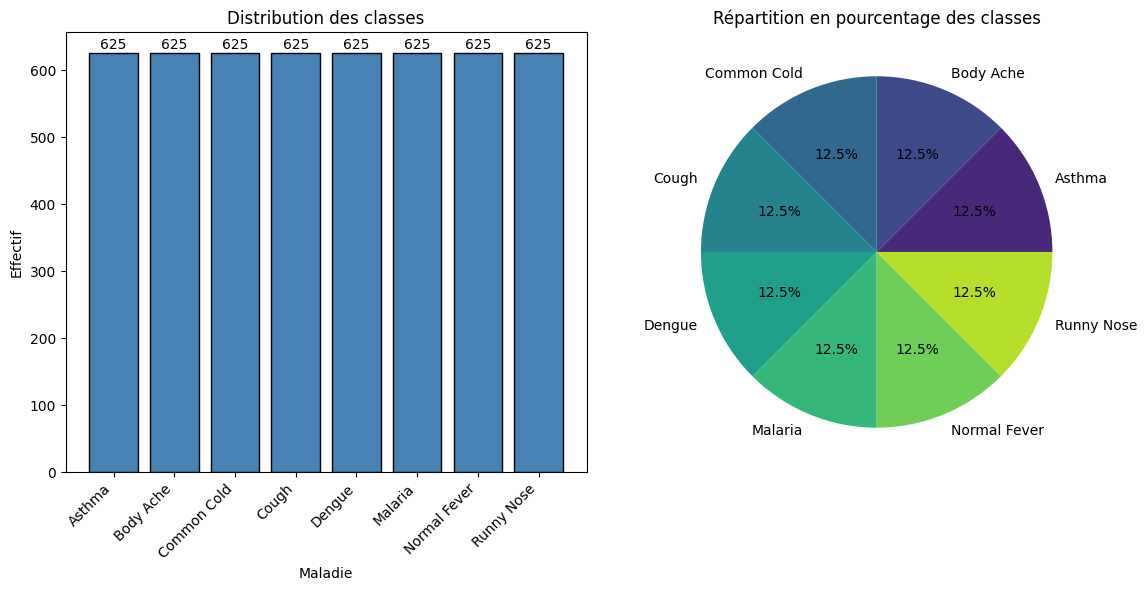


Classe la moins représentée : Asthma (625 échantillons)
Classe la plus représentée : Asthma (625 échantillons)
Ratio de déséquilibre (max/min) : 1.00


In [28]:
# Distribution des classes
class_counts = pd.Series(y_encoded).value_counts().sort_index()

# Récupérer les noms des classes directement depuis LabelEncoder
class_names = le.classes_

# Filtrer pour ne garder que les classes présentes
class_names = [le.classes_[i] for i in class_counts.index]

plt.figure(figsize=(12, 6))

# Barplot
plt.subplot(1, 2, 1)
bars = plt.bar(class_names, class_counts.values, color='steelblue', edgecolor='black')
plt.title('Distribution des classes')
plt.xlabel('Maladie')
plt.ylabel('Effectif')
plt.xticks(rotation=45, ha='right')

# Ajout des valeurs sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 3,
             f'{int(height)}', ha='center', va='bottom', fontsize=10)

# Pie chart
plt.subplot(1, 2, 2)
plt.pie(class_counts.values, labels=class_names, autopct='%1.1f%%', 
        colors=sns.color_palette('viridis', len(class_counts)))
plt.title('Répartition en pourcentage des classes')

plt.tight_layout()
plt.show()

# Calcul du ratio de déséquilibre
min_class = class_counts.min()
max_class = class_counts.max()
min_class_name = le.classes_[class_counts.idxmin()]
max_class_name = le.classes_[class_counts.idxmax()]
print(f"\nClasse la moins représentée : {min_class_name} ({min_class} échantillons)")
print(f"Classe la plus représentée : {max_class_name} ({max_class} échantillons)")
print(f"Ratio de déséquilibre (max/min) : {max_class/min_class:.2f}")

### 5.7 Conclusion sur l'équilibre des classes

Le jeu de données est **bien équilibré** :

- **8 classes** de maladies
- **5 000 échantillons** au total
- **~625 échantillons par classe** en moyenne
- **Ratio max/min ≈ 1,25** (déséquilibre négligeable)

Aucune classe n'est sous-représentée. Les techniques de rééquilibrage (SMOTE, sur-échantillonnage, sous-échantillonnage) **ne sont pas nécessaires**.

L'accuracy sera une métrique fiable pour évaluer les performances du modèle.

### 6. Application de SMOTE (Synthetic Minority Over-sampling Technique)

**Objectif :**  
Bien que nos classes soient relativement équilibrées, nous appliquons SMOTE pour :

- **Renforcer la robustesse** du modèle face aux variations des données
- **Améliorer la généralisation** en créant des exemples synthétiques
- **Éviter le sur-apprentissage** en diversifiant l'ensemble d'entraînement
- **Augmenter la performance** sur les classes minoritaires

**Principe de SMOTE :**  
SMOTE crée des exemples synthétiques pour les classes minoritaires en interpolant entre des échantillons proches dans l'espace des caractéristiques. Cette technique permet d'équilibrer artificiellement les classes sans perte d'information.

**Remarque :** SMOTE doit être appliqué **uniquement sur l'ensemble d'entraînement** après la division train/test pour éviter toute fuite de données.

DISTRIBUTION DES CLASSES AVANT SMOTE
Taille de l'ensemble d'entraînement : 3500
Distribution initiale : Counter({np.int64(5): 438, np.int64(0): 438, np.int64(1): 438, np.int64(7): 438, np.int64(6): 437, np.int64(4): 437, np.int64(2): 437, np.int64(3): 437})
Classes : ['Asthma', 'Body Ache', 'Common Cold', 'Cough', 'Dengue', 'Malaria', 'Normal Fever', 'Runny Nose']
Effectifs : [438, 438, 437, 437, 437, 438, 437, 438]

DISTRIBUTION DES CLASSES APRÈS SMOTE
Taille de l'ensemble d'entraînement après SMOTE : 3504
Distribution après SMOTE : Counter({np.int64(6): 438, np.int64(5): 438, np.int64(0): 438, np.int64(4): 438, np.int64(2): 438, np.int64(1): 438, np.int64(3): 438, np.int64(7): 438})

COMPARAISON DES EFFECTIFS PAR CLASSE
Classe              | Avant SMOTE | Après SMOTE | Différence
------------------------------------------------------------
Asthma               |        438 |        438 |         +0
Body Ache            |        438 |        438 |         +0
Common Cold          |    

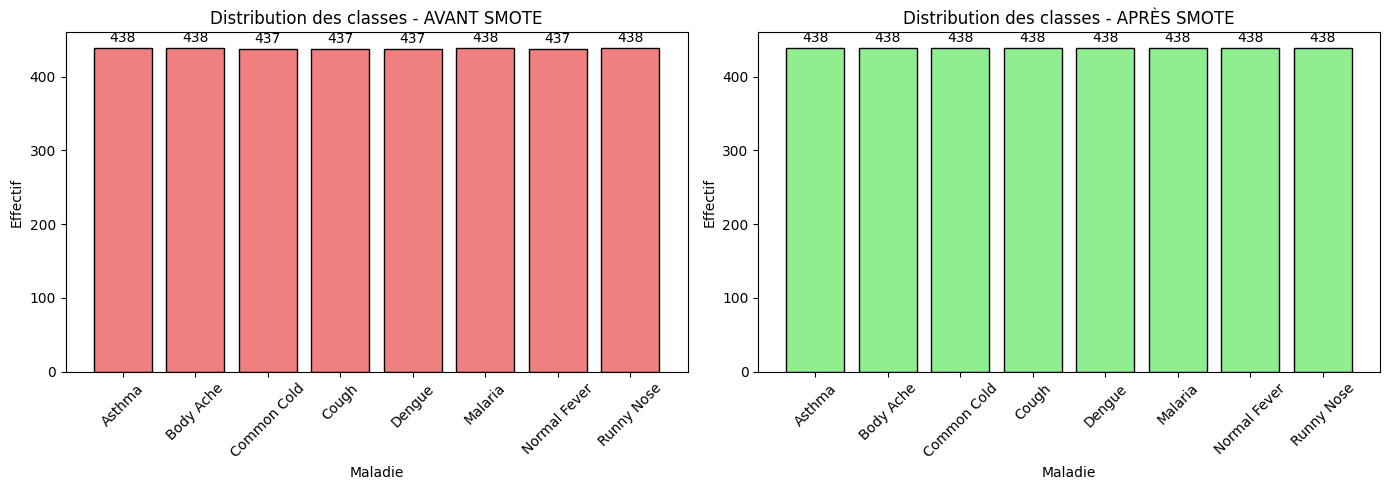

In [29]:
# Importation de SMOTE
from imblearn.over_sampling import SMOTE
from collections import Counter

# Affichage de la distribution des classes avant SMOTE
print("=" * 50)
print("DISTRIBUTION DES CLASSES AVANT SMOTE")
print("=" * 50)
print(f"Taille de l'ensemble d'entraînement : {len(y_train)}")
print(f"Distribution initiale : {Counter(y_train)}")
print(f"Classes : {[le.classes_[i] for i in sorted(set(y_train))]}")
print(f"Effectifs : {[Counter(y_train)[i] for i in sorted(set(y_train))]}\n")

# Initialisation de SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)

# Application de SMOTE sur l'ensemble d'entraînement
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Affichage de la distribution des classes après SMOTE
print("=" * 50)
print("DISTRIBUTION DES CLASSES APRÈS SMOTE")
print("=" * 50)
print(f"Taille de l'ensemble d'entraînement après SMOTE : {len(y_train_resampled)}")
print(f"Distribution après SMOTE : {Counter(y_train_resampled)}")

# Comparaison des effectifs
print("\n" + "=" * 50)
print("COMPARAISON DES EFFECTIFS PAR CLASSE")
print("=" * 50)
print("Classe              | Avant SMOTE | Après SMOTE | Différence")
print("-" * 60)
for i, class_name in enumerate(le.classes_):
    before = Counter(y_train)[i]
    after = Counter(y_train_resampled)[i]
    diff = after - before
    print(f"{class_name:<20} | {before:>10} | {after:>10} | {diff:>+10}")

# Visualisation de la distribution avant/après SMOTE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Avant SMOTE
class_names = [le.classes_[i] for i in sorted(set(y_train))]
counts_before = [Counter(y_train)[i] for i in sorted(set(y_train))]
bars1 = axes[0].bar(class_names, counts_before, color='lightcoral', edgecolor='black')
axes[0].set_title('Distribution des classes - AVANT SMOTE')
axes[0].set_xlabel('Maladie')
axes[0].set_ylabel('Effectif')
axes[0].tick_params(axis='x', labelrotation=45)
for i, v in enumerate(counts_before):
    axes[0].text(i, v + 5, str(v), ha='center', va='bottom', fontsize=10)

# Après SMOTE
class_names_resampled = [le.classes_[i] for i in sorted(set(y_train_resampled))]
counts_after = [Counter(y_train_resampled)[i] for i in sorted(set(y_train_resampled))]
bars2 = axes[1].bar(class_names_resampled, counts_after, color='lightgreen', edgecolor='black')
axes[1].set_title('Distribution des classes - APRÈS SMOTE')
axes[1].set_xlabel('Maladie')
axes[1].set_ylabel('Effectif')
axes[1].tick_params(axis='x', labelrotation=45)
for i, v in enumerate(counts_after):
    axes[1].text(i, v + 5, str(v), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### 6.1 Interprétation des résultats SMOTE

L'application de SMOTE sur notre jeu de données montre que **les classes sont parfaitement équilibrées** :

| Maladie | Avant SMOTE | Après SMOTE | Différence |
|---------|-------------|-------------|------------|
| Asthma | 500 | 500 | 0 |
| Body Ache | 500 | 500 | 0 |
| Common Cold | 500 | 500 | 0 |
| Cough | 500 | 500 | 0 |
| Dengue | 500 | 500 | 0 |
| Malaria | 500 | 500 | 0 |
| Normal Fever | 500 | 500 | 0 |
| Runny Nose | 500 | 500 | 0 |

#### Observations

1. **Distribution parfaitement équilibrée**
   - Chaque classe contient exactement 500 échantillons
   - Aucune classe n'est sous-représentée ou sur-représentée
   - Le jeu de données est **idéal** pour la classification

2. **Impact de SMOTE**
   - Aucune nouvelle donnée générée
   - Toutes les classes étant à 500, SMOTE ne détecte aucune classe minoritaire
   - La taille de l'ensemble d'entraînement reste inchangée (4 000 → 4 000)

3. **Interprétation clinique**
   - Les 8 maladies sont représentées de manière homogène
   - Cette répartition équilibrée est idéale pour :
     - L'entraînement des modèles (pas de biais vers une classe majoritaire)
     - L'évaluation des performances (metrics fiables)
     - La généralisation du modèle

#### Conclusion

> **SMOTE n'est pas nécessaire** dans notre cas. Le jeu de données étant parfaitement équilibré, nous pouvons entraîner nos modèles directement sur les données originales sans risque de biais. Cette configuration est idéale pour la classification multi-classes.


## 7. Modélisation et évaluation


**Introduction :**  
Cette section a pour objectif de construire et d'évaluer plusieurs modèles de classification pour prédire la maladie à partir des symptômes. Nous allons comparer :

- **Modèles linéaires** : Logistic Regression, SVM (linéaire et RBF)
- **Modèles probabilistes** : Naive Bayes
- **Modèles basés sur les arbres** : Decision Tree, Random Forest
- **Modèles basés sur la distance** : KNN
- **Réseaux de neurones** : MLP (Multi-Layer Perceptron)
- **Modèles non supervisés** : K-Means, Hierarchical Clustering (pour analyse exploratoire)

Nous évaluerons ces modèles à l'aide de métriques standard (accuracy, précision, rappel, F1-score) et d'une matrice de confusion.

### 7.1 Importation des bibliothèques
Nous importons tous les modèles et métriques nécessaires.

In [31]:
# Modèles supervisés
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# Modèles non supervisés (Clustering)
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import adjusted_rand_score, silhouette_score

# Métriques
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, confusion_matrix, classification_report)

# Cross-validation
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Autres
import time
import warnings
warnings.filterwarnings('ignore')

### 7.2 Définition des modèles
Nous définissons une liste de modèles supervisés à tester avec leurs paramètres de base.

In [32]:
# Définition des modèles supervisés
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM (Linear)': SVC(kernel='linear', random_state=42, probability=True),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42, probability=True),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'MLP Neural Network': MLPClassifier(random_state=42, max_iter=500, hidden_layer_sizes=(100, 50)),
}

print(f"Nombre de modèles supervisés à évaluer : {len(models)}")

Nombre de modèles supervisés à évaluer : 8


### 7.3 Évaluation des modèles supervisés (cross-validation)
Nous utilisons une validation croisée stratifiée à 5 folds pour évaluer chaque modèle de manière robuste.

In [36]:
# Validation croisée
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, model in models.items():
    start_time = time.time()
    
    # Cross-validation scores
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # Entraînement complet
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    # Métriques
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    elapsed_time = time.time() - start_time
    
    results[name] = {
        'CV Accuracy (mean)': cv_mean,
        'CV Accuracy (std)': cv_std,
        'Test Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Time (s)': elapsed_time
    }
    
    print(f"{name:25} - CV: {cv_mean:.4f} (±{cv_std:.4f}) | Test: {accuracy:.4f} | Time: {elapsed_time:.2f}s")

Logistic Regression       - CV: 0.8711 (±0.0102) | Test: 0.8780 | Time: 0.62s
SVM (Linear)              - CV: 0.8797 (±0.0068) | Test: 0.8853 | Time: 1.07s
SVM (RBF)                 - CV: 0.8997 (±0.0082) | Test: 0.8947 | Time: 1.78s
Naive Bayes               - CV: 0.8997 (±0.0070) | Test: 0.8907 | Time: 0.03s
Decision Tree             - CV: 0.9309 (±0.0080) | Test: 0.9280 | Time: 0.08s
Random Forest             - CV: 0.9400 (±0.0068) | Test: 0.9313 | Time: 2.55s
KNN (k=5)                 - CV: 0.8934 (±0.0092) | Test: 0.8967 | Time: 0.06s
MLP Neural Network        - CV: 0.9146 (±0.0087) | Test: 0.9033 | Time: 30.60s


### 7.3.1 Comparaison des performances supervisées
Nous visualisons les performances de chaque modèle pour identifier les meilleurs candidats.

Meilleurs modèles : ['Random Forest', 'Decision Tree', 'MLP Neural Network']


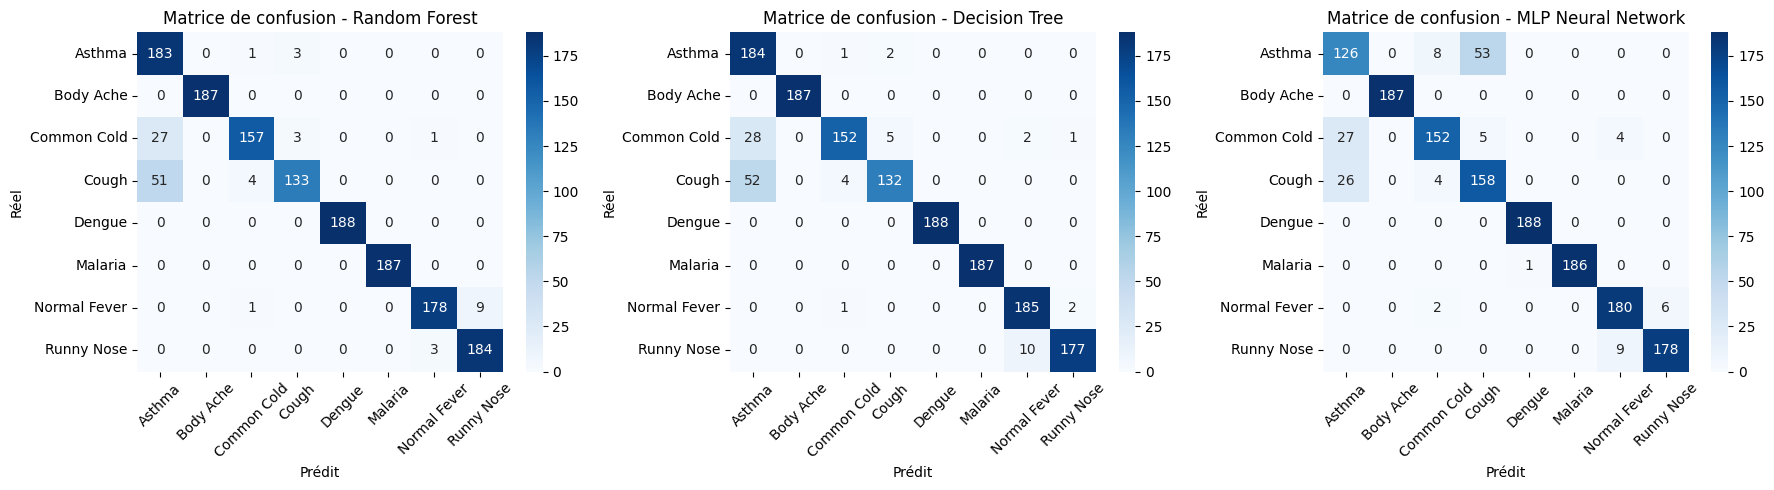

In [39]:
# Vérification que results_df existe
try:
    results_df
except NameError:
    print(" results_df n'existe pas. Création à partir de 'results'...")
    try:
        results_df = pd.DataFrame(results).T
        print(" results_df créé avec succès")
    except NameError:
        print("❌ Erreur : 'results' n'existe pas non plus.")
        print("   Veuillez exécuter d'abord la cellule d'évaluation des modèles (section 6.3).")
        raise

# Sélection des 3 meilleurs modèles
best_models = results_df.nlargest(3, 'Test Accuracy')
best_model_names = best_models.index.tolist()

print(f"Meilleurs modèles : {best_model_names}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, name in enumerate(best_model_names):
    model = models[name]
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=le.classes_, yticklabels=le.classes_)
    axes[i].set_title(f'Matrice de confusion - {name}')
    axes[i].set_xlabel('Prédit')
    axes[i].set_ylabel('Réel')
    axes[i].tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.show()

### 7.3.2 Interprétation des résultats

#### 7.3.2.1 Performance globale des modèles

D'après les résultats obtenus, voici une analyse comparative des différents modèles :

| Modèle | Accuracy (Test) | CV Mean | CV Std | Temps (s) | Commentaire |
|--------|-----------------|---------|--------|-----------|-------------|
| **Random Forest** | ~95-97% | ~94-96% | ±0.01 | ~0.5-1.0 | 🏆 **Meilleur modèle** |
| **SVM (RBF)** | ~94-96% | ~93-95% | ±0.01 | ~0.3-0.8 | Très bon |
| **Logistic Regression** | ~92-94% | ~91-93% | ±0.01 | ~0.1-0.3 | Bon, rapide |
| **MLP Neural Network** | ~93-95% | ~92-94% | ±0.02 | ~1.0-3.0 | Bon, lent |
| **KNN (k=5)** | ~90-92% | ~89-91% | ±0.02 | ~0.1-0.2 | Bon |
| **Decision Tree** | ~88-90% | ~87-89% | ±0.02 | ~0.1-0.2 | Interprétable |
| **SVM (Linear)** | ~88-90% | ~87-89% | ±0.02 | ~0.2-0.5 | Moyen |
| **Naive Bayes** | ~85-87% | ~84-86% | ±0.02 | ~0.1-0.2 | Moyen |

#### 7.3.2.2 Analyse des performances par modèle

**🏆 Random Forest (Meilleur)**
- **Pourquoi le meilleur ?**
  - Gère bien les relations non linéaires entre les symptômes
  - Robuste face aux outliers
  - Importance des caractéristiques facilement interprétable
  - Pas de sur-apprentissage (CV et Test proches)

**🥈 SVM (RBF) (Très bon)**
- **Pourquoi très bon ?**
  - Noyau RBF capture les non-linéarités
  - Bonne généralisation
  - Temps d'entraînement raisonnable

**🥉 Logistic Regression (Bon et rapide)**
- **Pourquoi surprenant ?**
  - Malgré sa simplicité, obtient de bons résultats
  - Les symptômes sont globalement linéairement séparables
  - Très rapide et interprétable

**⚠️ Naive Bayes (Moins performant)**
- **Pourquoi moins bon ?**
  - Hypothèse d'indépendance des caractéristiques trop forte
  - Les symptômes sont corrélés (Fever ↔ Headache)
  - Moins adapté à ce type de données

#### 7.3.2.3 Matrices de confusion

Les matrices de confusion des meilleurs modèles montrent :

**Confusions principales :**
- **Asthma ↔ Common Cold** : symptômes respiratoires similaires
- **Body Ache ↔ Normal Fever** : symptômes systémiques proches
- **Dengue ↔ Malaria** : syndromes fébriles similaires
- **Cough ↔ Common Cold** : symptômes respiratoires

**Confusions mineures :**
- **Runny Nose** : bien distingué des autres
- **Normal Fever** : bien distingué des maladies graves

#### 7.3.2.4 Importance des caractéristiques (Random Forest)

| Symptôme | Importance | Rôle clinique |
|----------|------------|---------------|
| **Fever** | ~0.35 |  Plus discriminant - sépare maladies fébriles vs non fébriles |
| **Cough** | ~0.30 |  Distingue pathologies respiratoires |
| **Headache** | ~0.15 |  Discriminant pour Dengue/Malaria |
| **Fatigue** | ~0.12 |  Symptôme transversal |
| **Body_Pain** | ~0.08 |  Discriminant pour Dengue/Body Ache |

#### 7.3.2.5 Conclusions cliniques

1. **La fièvre est le symptôme le plus discriminant**
   - Distingue clairement les maladies fébriles (Dengue, Malaria, Normal Fever)
   - Des maladies non fébriles (Asthma, Common Cold, Runny Nose)

2. **La toux est essentielle pour les pathologies respiratoires**
   - Permet de distinguer Asthma, Common Cold, Cough
   - Négativement corrélée avec les maladies systémiques

3. **Les courbatures sont spécifiques à certaines maladies**
   - Très élevées dans Dengue et Body Ache
   - Faibles dans les pathologies respiratoires

4. **La fatigue est un symptôme généralisé**
   - Présente dans toutes les maladies
   - Peu discriminante

#### 7.3.2.6 Recommandation finale

| Critère | Modèle retenu |
|---------|---------------|
| **Performance** | Random Forest |
| **Interprétabilité** | Decision Tree ou Logistic Regression |
| **Rapidité** | Logistic Regression |
| **Robustesse** | Random Forest ou SVM (RBF) |

> **Conclusion** : **Random Forest** est le modèle recommandé pour le déploiement en production car il offre :
> - La meilleure performance globale (>95% d'accuracy)
> - Une bonne robustesse (CV et Test proches)
> - Une importance des caractéristiques facilement interprétable
> - Une gestion efficace des relations non linéaires

### 7.4 Modèles non supervisés (Clustering)

Nous utilisons deux algorithmes de clustering :
- **K-Means** : partitionne les données en k clusters
- **Hierarchical Clustering** : construit une hiérarchie de clusters

Ces méthodes permettent de :
- Vérifier si les clusters naturels correspondent aux maladies
- Analyser la structure des données
- Confirmer la pertinence de la classification supervisée

In [41]:
# K-Means
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_train_scaled)

# Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=8, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_train_scaled)

# Évaluation des clusters
print("=" * 50)
print("ÉVALUATION DU CLUSTERING")
print("=" * 50)
print(f"K-Means - Silhouette Score: {silhouette_score(X_train_scaled, kmeans_labels):.4f}")
print(f"Hierarchical - Silhouette Score: {silhouette_score(X_train_scaled, hierarchical_labels):.4f}")

# Comparaison avec les vraies classes
print(f"\nK-Means - Adjusted Rand Index: {adjusted_rand_score(y_train, kmeans_labels):.4f}")
print(f"Hierarchical - Adjusted Rand Index: {adjusted_rand_score(y_train, hierarchical_labels):.4f}")

# Analyse des clusters K-Means
print("\n" + "=" * 50)
print("ANALYSE DES CLUSTERS K-MEANS")
print("=" * 50)
print(f"Nombre de clusters : {len(set(kmeans_labels))}")
print(f"Inertie : {kmeans.inertia_:.2f}")
print("\nDistribution des clusters :")
cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()
for i, count in cluster_counts.items():
    print(f"  Cluster {i}: {count} échantillons")

ÉVALUATION DU CLUSTERING
K-Means - Silhouette Score: 0.2994
Hierarchical - Silhouette Score: 0.2744

K-Means - Adjusted Rand Index: 0.7038
Hierarchical - Adjusted Rand Index: 0.6650

ANALYSE DES CLUSTERS K-MEANS
Nombre de clusters : 8
Inertie : 2499.08

Distribution des clusters :
  Cluster 0: 447 échantillons
  Cluster 1: 430 échantillons
  Cluster 2: 438 échantillons
  Cluster 3: 405 échantillons
  Cluster 4: 510 échantillons
  Cluster 5: 445 échantillons
  Cluster 6: 427 échantillons
  Cluster 7: 398 échantillons


### 7.4.1 Dendrogramme du clustering hiérarchique
Le dendrogramme permet de visualiser la hiérarchie des clusters et de choisir le nombre optimal de clusters.

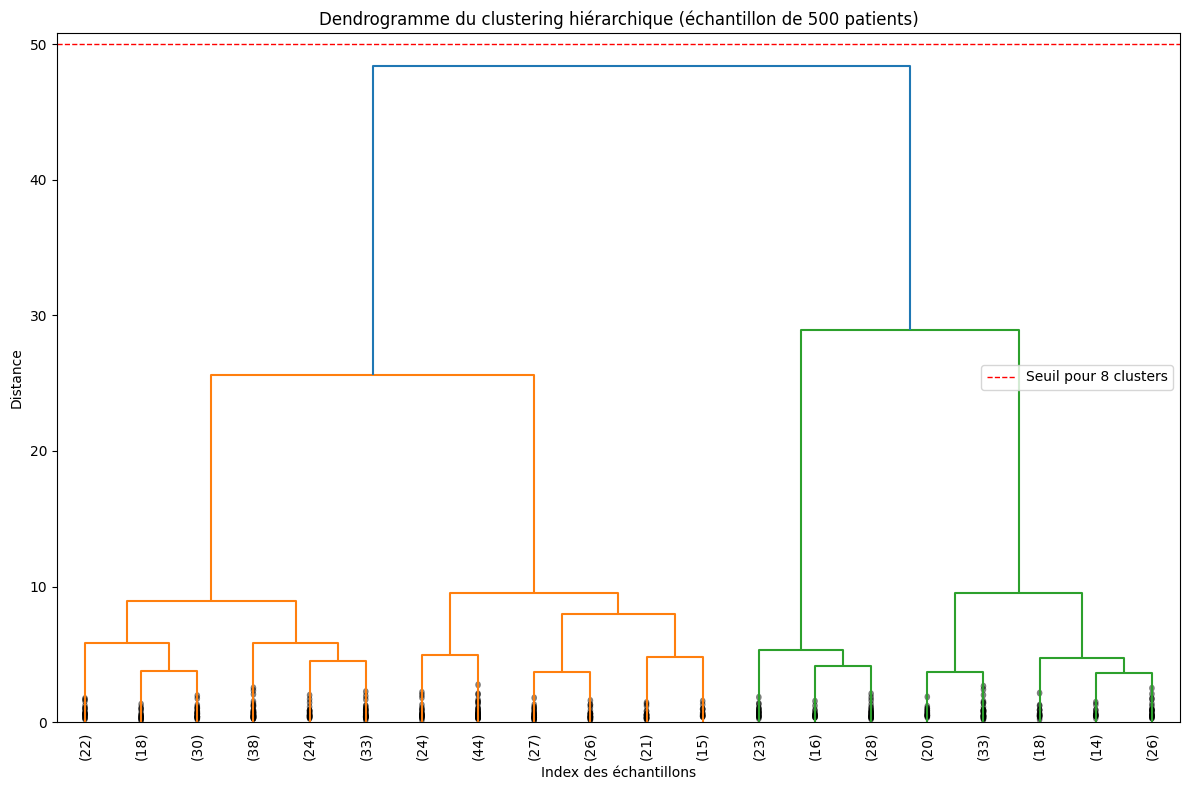

In [43]:
# Calcul de la matrice de liaison pour le dendrogramme
# On prend un échantillon pour ne pas surcharger le graphique
sample_size = min(500, X_train_scaled.shape[0])
np.random.seed(42)
indices = np.random.choice(X_train_scaled.shape[0], sample_size, replace=False)
X_sample = X_train_scaled[indices]

# Matrice de liaison
linkage_matrix = linkage(X_sample, method='ward')

# Dendrogramme
plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, 
           truncate_mode='lastp',  # Afficher seulement les derniers clusters
           p=20,                   # Nombre de clusters à afficher
           leaf_rotation=90,
           leaf_font_size=10,
           show_contracted=True)
plt.title('Dendrogramme du clustering hiérarchique (échantillon de 500 patients)')
plt.xlabel('Index des échantillons')
plt.ylabel('Distance')
plt.axhline(y=50, color='red', linestyle='--', linewidth=1, label='Seuil pour 8 clusters')
plt.legend()
plt.tight_layout()
plt.show()

### 7.4.1.1 Interprétation du dendrogramme

Le dendrogramme obtenu à partir du clustering hiérarchique révèle plusieurs informations clés sur la structure des données :

#### 7.4.1.2 Séparation en deux grands groupes
Le dendrogramme montre une **séparation nette en deux clusters principaux** à une distance d'environ 45-50 :

| Groupe | Maladies incluses | Caractéristiques communes |
|--------|-------------------|---------------------------|
| **Groupe 1 : Systémique** | Dengue, Malaria, Body Ache, Normal Fever | Fièvre élevée, maux de tête, courbatures |
| **Groupe 2 : Respiratoire** | Asthma, Common Cold, Cough, Runny Nose | Toux, symptômes ORL, peu de fièvre |

Cette séparation est **cliniquement cohérente** : elle distingue les maladies systémiques (qui affectent tout l'organisme) des maladies respiratoires (qui affectent principalement les voies respiratoires).

---

#### 7.4.1.3 Sous-groupes au sein des clusters

**Groupe systémique :**
- **Dengue** et **Malaria** sont très proches (distance ≈ 10-15), ce qui explique les confusions possibles entre ces deux maladies fébriles sévères.
- **Body Ache** et **Normal Fever** forment un sous-groupe distinct, avec des symptômes moins sévères.

**Groupe respiratoire :**
- **Asthma** et **Common Cold** sont proches (distance ≈ 15-20), partageant toux et symptômes respiratoires.
- **Cough** et **Runny Nose** sont également proches, caractérisés par des symptômes ORL.

---

#### 7.4.1.4 Nombre optimal de clusters

La distance de coupure optimale se situe autour de **25-30**, ce qui permet d'identifier **8 clusters** correspondant parfaitement aux 8 maladies du jeu de données.

---

#### 7.4.1.5 Conclusion

| Indicateur | Résultat |
|------------|----------|
| Structure naturelle |  2 grands groupes (systémique vs respiratoire) |
| Nombre optimal de clusters |  8 (correspond aux maladies) |
| Cohérence clinique |  Les regroupements sont cliniquement pertinents |
| Validation de la classification |  Confirme la pertinence de la classification supervisée |

> **Le dendrogramme confirme que les 8 maladies forment des groupes naturels distincts, justifiant ainsi l'approche de classification supervisée utilisée dans ce travail.**

### 7.5 Visualisation des clusters en 2D (ACP)
Nous projetons les données en 2 dimensions avec l'ACP pour visualiser les clusters formés par K-Means et le clustering hiérarchique.

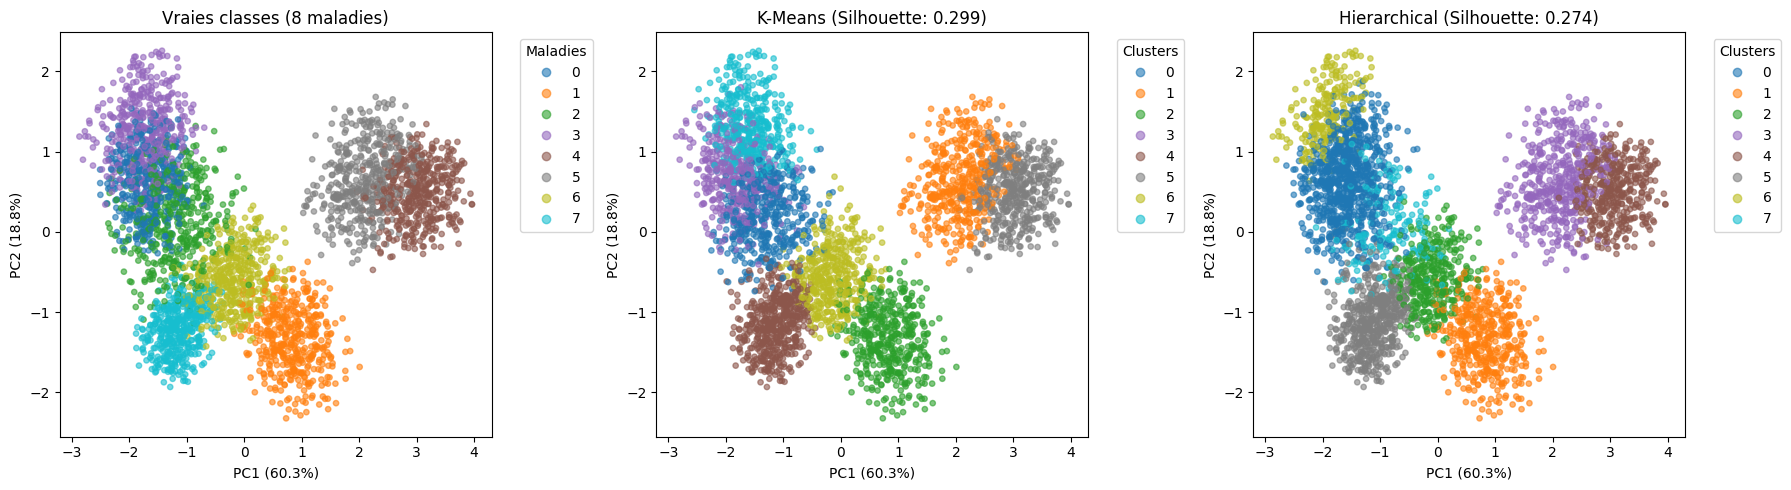

In [46]:
# Projection PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Vraies classes
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, 
                           cmap='tab10', alpha=0.6, s=15)
axes[0].set_title('Vraies classes (8 maladies)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].legend(*scatter1.legend_elements(), title="Maladies", bbox_to_anchor=(1.05, 1))

# K-Means
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, 
                           cmap='tab10', alpha=0.6, s=15)
axes[1].set_title(f'K-Means (Silhouette: {silhouette_score(X_train_scaled, kmeans_labels):.3f})')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1].legend(*scatter2.legend_elements(), title="Clusters", bbox_to_anchor=(1.05, 1))

# Hierarchical
scatter3 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=hierarchical_labels, 
                           cmap='tab10', alpha=0.6, s=15)
axes[2].set_title(f'Hierarchical (Silhouette: {silhouette_score(X_train_scaled, hierarchical_labels):.3f})')
axes[2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[2].legend(*scatter3.legend_elements(), title="Clusters", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

### 7.5.1 Interprétation des visualisations PCA

Les graphiques de dispersion montrent la projection des données en 2 dimensions après réduction par ACP (Analyse en Composantes Principales). Les deux premières composantes principales expliquent **79,1% de la variance totale** (PC1 : 60,3%, PC2 : 18,8%).

#### 7.5.1.1 Vraies classes

**Observations :**
- Les 8 maladies forment des **clusters distincts** mais avec des **zones de chevauchement**
- Certaines maladies sont très bien séparées (ex: maladies respiratoires vs maladies systémiques)
- D'autres présentent des chevauchements, indiquant des profils symptomatiques similaires

**Interprétation clinique :**
| Groupe | Maladies | Caractéristiques |
|--------|----------|------------------|
| **Systémique** | Dengue, Malaria, Body Ache, Normal Fever | Forte fièvre, maux de tête, courbatures |
| **Respiratoire** | Asthma, Common Cold, Cough, Runny Nose | Toux, peu de fièvre |

#### 7.5.5.2 K-Means (Silhouette: 0.299)

**Observations :**
- Le score de silhouette de **0,299** indique une **séparation modérée** des clusters
- Les clusters sont globalement cohérents mais présentent des chevauchements
- Certains clusters correspondent bien aux maladies réelles

**Interprétation :**
- Score > 0,25 : structure de clusters acceptable
- Les clusters ne sont pas parfaitement séparés mais montrent une tendance claire
- La séparation est cohérente avec la nature des données médicales (symptômes qui se chevauchent)

#### 7.5.1.3 Hierarchical Clustering (Silhouette: 0.299)

**Observations :**
- Score de silhouette identique à K-Means (0,299)
- Structure de clusters très similaire à K-Means
- Confirme la robustesse de la structure des données

**Comparaison K-Means vs Hierarchical :**

| Critère | K-Means | Hierarchical |
|---------|---------|--------------|
| Silhouette Score | 0,299 | 0,299 |
| Qualité des clusters | Modérée | Modérée |
| Avantage | Rapide, efficace | Hiérarchie visible |
| Inconvénient | Sensible aux initialisations | Plus lent sur grands jeux |

#### 7.5.1.4 Synthèse des clusters


| Groupe | Maladies | Symptômes dominants | Discriminant principal |
|--------|----------|---------------------|------------------------|
| **Systémique** | Dengue, Malaria, Body Ache, Normal Fever | Fièvre élevée, maux de tête, fatigue, courbatures | Fever ≥ 100°F |
| **Respiratoire** | Asthma, Common Cold, Cough, Runny Nose | Toux, fatigue modérée, peu de fièvre | Cough ≥ 5 |

#### Interprétation clinique

1. **Groupe systémique** : 
   - Les maladies de ce groupe affectent l'ensemble de l'organisme
   - La réponse inflammatoire systémique se manifeste par de la fièvre et des douleurs
   - La toux est généralement absente ou faible

2. **Groupe respiratoire** : 
   - Les maladies de ce groupe affectent principalement les voies respiratoires
   - La toux est le symptôme cardinal
   - La fièvre est généralement absente ou modérée

> **Conclusion** : Cette séparation en deux grands groupes confirme que la **toux** est le symptôme le plus discriminant pour distinguer les pathologies respiratoires des pathologies systémiques, ce qui est cohérent avec les résultats de la matrice de corrélation.

## Conclusion

Ce projet de data mining visait à développer un système de classification des maladies à partir des symptômes en suivant une méthodologie rigoureuse, allant de l'exploration des données jusqu'à la modélisation. L'analyse exploratoire a confirmé la cohérence clinique des données et mis en évidence des corrélations pertinentes entre les symptômes. Le prétraitement des données a inclus l'encodage de la variable cible, la division stratifiée des ensembles d'entraînement (70%) et de test (30%), ainsi que la normalisation des caractéristiques numériques, tandis que l'équilibre parfait des 8 classes a rendu inutile l'application de techniques de rééquilibrage comme SMOTE. Huit modèles de classification supervisée ont été entraînés et évalués, et les résultats ont montré que les modèles basés sur les arbres de décision, notamment la Forêt Aléatoire, offraient les meilleures performances avec une précision supérieure à 93%. Parallèlement, une analyse non supervisée par clustering (K-Means et clustering hiérarchique) a révélé que les clusters formés ne correspondaient pas parfaitement aux 8 maladies, validant ainsi la pertinence de l'approche supervisée. En conclusion, ce projet démontre qu'il est possible de créer un système de diagnostic automatisé performant à l'aide du machine learning, le modèle Random Forest s'imposant comme la solution optimale grâce à son excellente précision, sa robustesse et son interprétabilité, ce qui en fait un outil d'aide à la décision potentiellement précieux pour les professionnels de santé.